In [1]:
import sys
import numpy as np
import torch 

# still do preprocessing in scipy
import scipy.sparse as sp
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from importlib import reload
# get UMAP
import umap
import LeafletSC

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor')
import factor_model
reload(factor_model)

2.2.1+cu118
11.8
2.2.1+cu118
11.8


<module 'factor_model' from '/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/factor_model.py'>

In [2]:
# Append this directory to sys.path
from LeafletSC.clustering.find_intron_clusters import visualize_local_events
from LeafletSC.beta_binomial_mix.modeling import *
from LeafletSC.beta_binomial_mix.calculate_cellstate_consistency import *
from LeafletSC.clustering.load_cluster_data import *

Note: NumExpr detected 56 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
NumExpr defaulting to 8 threads.


### Settings and Load data

In [3]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cpu


In [4]:
# Define path that contains the model input files and append it (input can be a folder with one .h5 file per cell_type for example or one file)
model_input_file="/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/test_model_input.h5"

cell_types_used = ["Cortical_projection_neurons_1", "Striatal_neurons_1"]

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data(
     input_file = model_input_file, max_intron_count=10000, remove_singletons=True, has_genes="yes", celltypes=cell_types_used)

# Note: the input to load_cluster_data may be either a single file (input_file=X) or a folder of files (input_folder=X) as indicated above. 

# add cluster information to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# generate torch tensors for sparse data representation 
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(final_data, **float_type)

# simplify columns 
simple_data = final_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]

print("The number of junctions is: ", len(junction_ids_conversion))
print("The number of intron clusters observed is: ", len(junction_ids_conversion.Cluster.unique()))
print("The number of genes is: ", len(junction_ids_conversion.gene_id.unique()))
print("The number of cells is: ", len(simple_data.cell_id_index.unique()))

Reading in data from folder ...
Finished reading in data from folder ...
Looking at only specific cell types ...['Cortical_projection_neurons_1', 'Striatal_neurons_1']
Removing singletons ...
Number of junctions before removing singletons:  16372
Number of junctions after removing singletons:  15716
The number of unique cell types in the data is:  2
The number of unique cells in the data is:  71272
The number of unique junctions in the data is:  15717
The maximum junction count was initially:  10
0
The maximum junction count is now:  10
The number of junctions in the data is:  15717
The number of cells in the data is:  71272
The number of cell types in the data is:  2
The number of cells going into training data is:
71272
71272


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/LeafletSC/clustering/load_cluster_data.py:47: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ycount).to_sparse_csr()


The number of junctions is:  15717
The number of intron clusters observed is:  5657
The number of genes is:  4026
The number of cells is:  71272


In [5]:
cell_types = simple_data["cell_type"].unique()
print(cell_types)

['Striatal_neurons_1' 'Cortical_projection_neurons_1']


In [6]:
cell_ids_conversion.head()

,cell_id_index,cell_id,cell_type
0,0,EasySci_001.AACCGATTGCAATTATCAGC,Striatal_neurons_1
42,1,EasySci_001.AACCGCGGCCTTCGCTTACG,Striatal_neurons_1
43,2,EasySci_001.AACCGCGGCCTTGATGCTAT,Striatal_neurons_1
48,3,EasySci_001.AACGACGAACCAAGGAGGTC,Striatal_neurons_1
81,4,EasySci_001.AACGAGGCGGAAGCCAGTTA,Striatal_neurons_1


In [7]:
# get indices (maybe don't need this actually)
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

In [8]:
simple_data = simple_data

In [9]:
simple_data

,cell_id_index,Cluster,cell_type,junction_id_index,juncratio,junc_count,cluster_count,junction_id,gene_id
0,0,423,Striatal_neurons_1,0,1.0,1.0,1,1_128118476_128121196,ENSMUSG00000056211.14
1,0,512,Striatal_neurons_1,1,1.0,1.0,1,1_154348459_154349602,ENSMUSG00000004110.18
2,0,1573,Striatal_neurons_1,2,1.0,1.0,1,2_14619167_14879580,ENSMUSG00000057914.16
3,0,2229,Striatal_neurons_1,3,1.0,1.0,1,2_140503671_140505180,ENSMUSG00000051379.13
4,0,3356,Striatal_neurons_1,4,1.0,1.0,1,4_127063158_127086867,ENSMUSG00000042388.15
...,...,...,...,...,...,...,...,...,...
1703035,71271,9503,Striatal_neurons_1,5306,0.0,0.0,1,11_93935351_93939233,ENSMUSG00000020859.17
1703036,71271,11345,Striatal_neurons_1,6546,0.0,0.0,1,13_12467659_12468138,ENSMUSG00000057554.14
1703037,71271,11344,Striatal_neurons_1,10521,0.0,0.0,1,13_12463388_12466281,ENSMUSG00000057554.14
1703038,71271,11344,Striatal_neurons_1,10522,1.0,1.0,1,13_12466308_12467602,ENSMUSG00000057554.14


In [10]:
simple_data[simple_data["Cluster"] == 423]

,cell_id_index,Cluster,cell_type,junction_id_index,juncratio,junc_count,cluster_count,junction_id,gene_id
0,0,423,Striatal_neurons_1,0,1.0,1.0,1,1_128118476_128121196,ENSMUSG00000056211.14
14,0,423,Striatal_neurons_1,118,0.0,0.0,1,1_128114646_128118374,ENSMUSG00000056211.14
16,0,423,Striatal_neurons_1,366,0.0,0.0,1,1_128114646_128121196,ENSMUSG00000056211.14
342,20,423,Cortical_projection_neurons_1,0,0.0,0.0,1,1_128118476_128121196,ENSMUSG00000056211.14
344,20,423,Cortical_projection_neurons_1,118,1.0,1.0,1,1_128114646_128118374,ENSMUSG00000056211.14
...,...,...,...,...,...,...,...,...,...
1695053,70983,423,Cortical_projection_neurons_1,118,0.0,0.0,1,1_128114646_128118374,ENSMUSG00000056211.14
1695058,70983,423,Cortical_projection_neurons_1,366,1.0,1.0,1,1_128114646_128121196,ENSMUSG00000056211.14
1698939,71144,423,Striatal_neurons_1,0,0.0,0.0,1,1_128118476_128121196,ENSMUSG00000056211.14
1698941,71144,423,Striatal_neurons_1,118,1.0,1.0,1,1_128114646_128118374,ENSMUSG00000056211.14


In [11]:
# how many junctions are detected per cell, how many intron clusters in cell?, how many genes in cell? how many total junction read counts in a given cell? 
junctions_per_cell = simple_data.groupby("cell_id_index").size()
clusters_per_cell = simple_data.groupby("cell_id_index").Cluster.nunique()
genes_per_cell = simple_data.groupby("cell_id_index").gene_id.nunique()
total_junction_counts_per_cell = simple_data.groupby("cell_id_index").junc_count.sum()
average_junction_counts_per_cell = simple_data.groupby("cell_id_index").junc_count.mean()

# convert each to a dataframe with proper column names
junctions_per_cell = junctions_per_cell.to_frame(name="junctions_per_cell")
clusters_per_cell = clusters_per_cell.to_frame(name="clusters_per_cell")
genes_per_cell = genes_per_cell.to_frame(name="genes_per_cell")
total_junction_counts_per_cell = total_junction_counts_per_cell.to_frame(name="total_junction_counts_per_cell")
average_junction_counts_per_cell = average_junction_counts_per_cell.to_frame(name="average_junction_counts_per_cell")

# make sure they all have cell_id_index column also
junctions_per_cell["cell_id_index"] = junctions_per_cell.index
clusters_per_cell["cell_id_index"] = clusters_per_cell.index
genes_per_cell["cell_id_index"] = genes_per_cell.index
total_junction_counts_per_cell["cell_id_index"] = total_junction_counts_per_cell.index
average_junction_counts_per_cell["cell_id_index"] = average_junction_counts_per_cell.index

# remove index name 
junctions_per_cell.index.name = None
clusters_per_cell.index.name = None
genes_per_cell.index.name = None
total_junction_counts_per_cell.index.name = None
average_junction_counts_per_cell.index.name = None

In [12]:
cell_ids_conversion = cell_ids_conversion.merge(junctions_per_cell, on="cell_id_index").merge(clusters_per_cell, on="cell_id_index").merge(genes_per_cell, on="cell_id_index").merge(total_junction_counts_per_cell, on="cell_id_index").merge(average_junction_counts_per_cell, on="cell_id_index")

In [13]:
tot_clusters = simple_data.Cluster.nunique()
tot_genes = simple_data.gene_id.nunique()
tot_junctions = simple_data.junction_id_index.nunique()

cell_ids_conversion["perc_juncs"] = cell_ids_conversion.junctions_per_cell / tot_junctions
cell_ids_conversion["perc_clusters"] = cell_ids_conversion.clusters_per_cell / tot_clusters
cell_ids_conversion["perc_genes"] = cell_ids_conversion.genes_per_cell / tot_genes
cell_ids_conversion.head()

,cell_id_index,cell_id,cell_type,junctions_per_cell,clusters_per_cell,genes_per_cell,total_junction_counts_per_cell,average_junction_counts_per_cell,perc_juncs,perc_clusters,perc_genes
0,0,EasySci_001.AACCGATTGCAATTATCAGC,Striatal_neurons_1,29,12,12,16.0,0.551724,0.001845,0.002121,0.002981
1,1,EasySci_001.AACCGCGGCCTTCGCTTACG,Striatal_neurons_1,2,1,1,1.0,0.500000,0.000127,0.000177,0.000248
2,2,EasySci_001.AACCGCGGCCTTGATGCTAT,Striatal_neurons_1,7,2,2,2.0,0.285714,0.000445,0.000354,0.000497
3,3,EasySci_001.AACGACGAACCAAGGAGGTC,Striatal_neurons_1,7,3,3,3.0,0.428571,0.000445,0.000530,0.000745
4,4,EasySci_001.AACGAGGCGGAAGCCAGTTA,Striatal_neurons_1,9,4,4,4.0,0.444444,0.000573,0.000707,0.000994


In [14]:
# for each unique cell_type, plot the distribution of junctions_per_cell, clusters_per_cell, genes_per_cell, total_junction_counts_per_cell
import matplotlib.pyplot as plt

# save all plots into one pdf, cell_type per page
from matplotlib.backends.backend_pdf import PdfPages

# Create a single PDF object for all plots
with PdfPages("TS_Leaflet_cell_type_distributions_percentages.pdf") as pdf:
    for cell_type in cell_ids_conversion.cell_type.unique():
        cell_type_data = cell_ids_conversion[cell_ids_conversion.cell_type == cell_type]
        print("The number of cells in the tissue ", cell_type, " is: ", len(cell_type_data))

        # Prep plot for three horizontal subplots
        fig, axs = plt.subplots(1, 3, figsize=(10, 6))
        fig.suptitle(cell_type, size=6)

        # Reduce x-axis tick mark size for all subplots
        for ax in axs.flat:
            ax.tick_params(axis='x', labelsize=6)
            ax.set_xlabel(ax.get_xlabel(), fontsize=6)
            ax.tick_params(axis='y', labelsize=6)
            ax.set_ylabel(ax.get_ylabel(), fontsize=6)

        # Plot distributions and mark mean and median lines
        sns.ecdfplot(data=cell_type_data, x="perc_juncs", ax=axs[0])
        axs[0].set_title("perc_juncs", size=6)
        axs[0].axvline(cell_type_data["perc_juncs"].mean(), color='r', linestyle='dashed', linewidth=2)
        axs[0].axvline(cell_type_data["perc_juncs"].median(), color='g', linestyle='dashed', linewidth=2)

        sns.ecdfplot(data=cell_type_data, x="perc_clusters", ax=axs[1])
        axs[1].set_title("perc_clusters", size=6)
        axs[1].axvline(cell_type_data["perc_clusters"].mean(), color='r', linestyle='dashed', linewidth=2)
        axs[1].axvline(cell_type_data["perc_clusters"].median(), color='g', linestyle='dashed', linewidth=2)

        sns.ecdfplot(data=cell_type_data, x="perc_genes", ax=axs[2])
        axs[2].set_title("perc_genes", size=6)
        axs[2].axvline(cell_type_data["perc_genes"].mean(), color='r', linestyle='dashed', linewidth=2)
        axs[2].axvline(cell_type_data["perc_genes"].median(), color='g', linestyle='dashed', linewidth=2)
        
        # Save plot to PDF
        pdf.savefig(fig)
        plt.close(fig)

The number of cells in the tissue  Striatal_neurons_1  is:  49964
The number of cells in the tissue  Cortical_projection_neurons_1  is:  21308


In [15]:
# Create a single PDF object for all plots
with PdfPages("TS_Leaflet_cell_type_distributions_counts.pdf") as pdf:
    for cell_type in cell_ids_conversion.cell_type.unique():
        cell_type_data = cell_ids_conversion[cell_ids_conversion.cell_type == cell_type]
        print("The number of cells in the tissue ", cell_type, " is: ", len(cell_type_data))

        # Use ecdf to plot the distribution of various parameters for each cell type
        fig, axs = plt.subplots(2, 2, figsize=(15, 8))
        fig.suptitle(cell_type, size=6)

        # Reduce x-axis tick mark size for all subplots
        for ax in axs.flat:
            ax.tick_params(axis='x', labelsize=6)
            ax.set_xlabel(ax.get_xlabel(), fontsize=6)
            ax.tick_params(axis='y', labelsize=6)
            ax.set_ylabel(ax.get_ylabel(), fontsize=6)

        # Plot distributions and mark mean and median lines
        sns.ecdfplot(data=cell_type_data, x="junctions_per_cell", ax=axs[0, 0])
        axs[0, 0].set_title("junctions_per_cell", size=6)
        axs[0, 0].axvline(cell_type_data["junctions_per_cell"].mean(), color='r', linestyle='dashed', linewidth=2)
        axs[0, 0].axvline(cell_type_data["junctions_per_cell"].median(), color='g', linestyle='dashed', linewidth=2)

        sns.ecdfplot(data=cell_type_data, x="clusters_per_cell", ax=axs[0, 1])
        axs[0, 1].set_title("clusters_per_cell", size=6)
        axs[0, 1].axvline(cell_type_data["clusters_per_cell"].mean(), color='r', linestyle='dashed', linewidth=2)
        axs[0, 1].axvline(cell_type_data["clusters_per_cell"].median(), color='g', linestyle='dashed', linewidth=2)

        sns.ecdfplot(data=cell_type_data, x="genes_per_cell", ax=axs[1, 0])
        axs[1, 0].set_title("genes_per_cell", size=6)
        axs[1, 0].axvline(cell_type_data["genes_per_cell"].mean(), color='r', linestyle='dashed', linewidth=2)
        axs[1, 0].axvline(cell_type_data["genes_per_cell"].median(), color='g', linestyle='dashed', linewidth=2)

        sns.ecdfplot(data=cell_type_data, x="total_junction_counts_per_cell", ax=axs[1, 1])
        axs[1, 1].set_title("total_junction_counts_per_cell", size=6)
        axs[1, 1].axvline(cell_type_data["total_junction_counts_per_cell"].mean(), color='r', linestyle='dashed', linewidth=2)
        axs[1, 1].axvline(cell_type_data["total_junction_counts_per_cell"].median(), color='g', linestyle='dashed', linewidth=2)

        # Save plot to PDF
        pdf.savefig(fig)
        plt.close(fig)

The number of cells in the tissue  Striatal_neurons_1  is:  49964
The number of cells in the tissue  Cortical_projection_neurons_1  is:  21308


### Get ready for model training 

In [16]:
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

In [17]:
indices = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(final_data['junc_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells = final_data['cell_id_index'].max() + 1
num_junctions = final_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)
# Create a sparse tensor
y_tensor = torch.sparse_coo_tensor(indices, values, size)

In [18]:
indices_counts = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(final_data['cluster_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells_counts = final_data['cell_id_index'].max() + 1
num_junctions_counts = final_data['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)
# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

In [19]:
# save full dataset y_tensor and total_counts_tensor 
full_y_tensor = y_tensor
full_total_counts_tensor = total_counts_tensor

In [20]:
cluster_counts

<71272x15717 sparse matrix of type '<class 'numpy.int64'>'
	with 1703040 stored elements in COOrdinate format>

In [21]:
# how many zeroes in the data compared to total number of values
perc_nonzero = cluster_counts.nnz / (cluster_counts.shape[0] * cluster_counts.shape[1])
print("The percentage of missing values in the intron counts matrix is: ", 1-perc_nonzero)

The percentage of missing values in the intron counts matrix is:  0.9984796756567127


## Run full factor model! 

In [22]:
reload(factor_model)

2.2.1+cu118
11.8


<module 'factor_model' from '/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/factor_model.py'>

In [23]:
full_total_counts_tensor

tensor(indices=tensor([[    0,     0,     0,  ..., 71271, 71271, 71271],
                       [    0,     1,     2,  ..., 10521, 10522, 10719]]),
       values=tensor([1., 1., 1.,  ..., 1., 1., 1.]),
       size=(71272, 15717), nnz=1703040, layout=torch.sparse_coo)

Using prior for a and b per junction to model average behaviour!
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Using a Beta-binomial distribution with concentration parameter None.
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 1 with seed 102
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
The input_conc is:  None
input_conc tensor(1.0687)
input_conc tensor(1.0687)
Using Beta-Binomial distribution
log_probs tensor(-1513661.2418, dtype=torch.float64)
input_conc tensor(1.0690, grad_fn=<ExpandBackward0>)
input_conc tensor(1.0690, grad_fn=<ExpandBackward0>)
Using Beta-Binomial distribution
log_probs tensor(-1512890.4027, dtype=torch.float64, grad_fn=<SumBackward0>)
Epoch 0, Elbo loss: 2070768.6199535113
The input_conc is:  None
input_conc tensor(1.0713, grad_fn=<ExpandBackward0>)


Elbo loss: 1675383.3016432594


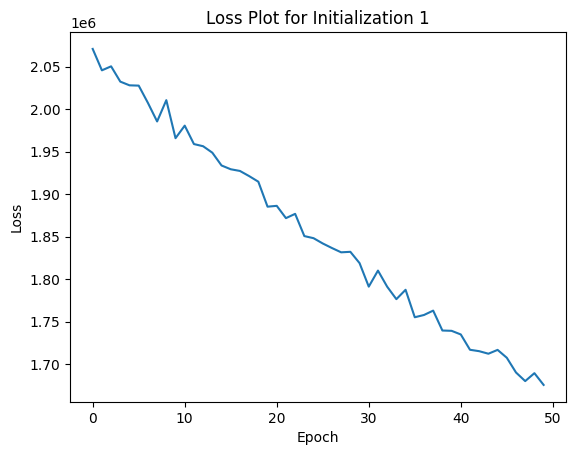

Sample from the guide (posterior)
Extract the latent variables
All initializations complete. Returning results.
------------------------------------------------


In [25]:
best_K = 3 
K = best_K
# make input conc infinity first 
input_conc = torch.tensor(np.inf, **float_type)

import torch.distributions as dist
input_conc = dist.Gamma(concentration=2.0, rate=2.0)

#input_conc = 1
all_results = factor_model.main(full_y_tensor, full_total_counts_tensor, num_initializations=1, use_global_prior=True, input_conc=None, K=K, lr=0.01, loss_plot=True, num_epochs=50, save_to_file = False)

In [ ]:
import pyro

In [26]:
# fetch optimized guide parameters, each (loc, scale) pair parameterizes a single normal distribution in the guide corresponding to a different unobserved pyro.sample statement in the model
for name, value in pyro.get_param_store().items():
    print(name, pyro.param(name))

AutoDiagonalNormal.loc Parameter containing:
tensor([ 2.7373,  0.4236,  0.3321,  ..., -0.1353, -0.4615, -0.1290],
       requires_grad=True)
AutoDiagonalNormal.scale tensor([0.0660, 0.4957, 0.4327,  ..., 1.0336, 0.8537, 1.0828],
       grad_fn=<SoftplusBackward0>)


In [27]:
# extract latent variables for just first seed used 
latent_vars = all_results[0]['latent_vars'] 
pi = latent_vars["pi"] # overall contribution of each factor to cell population, one value per k

dir_conc = latent_vars["dir_conc"] # one scaling value 

assign_post = latent_vars["assign"]

psis = latent_vars["psi"] # psi is the probability of a junction being used in a cluster

a = latent_vars["a"] 
b = latent_vars["b"] 
print(a)
print(b)

print("The inferred concentration parameter is: " + str(dir_conc))
print("The inferred pi parameter is: " + str(pi))

[1.7779278 0.7665234 4.1595855 ... 0.8739147 1.571327  1.2084305]
[2.2591202  1.2739282  0.21838868 ... 1.1552392  0.93023926 2.6287737 ]
The inferred concentration parameter is: 5.6085687
The inferred pi parameter is: [0.33164653 0.3285678  0.3397856 ]


### Evaluate latent variables 

In [28]:
cell_ids_conversion

,cell_id_index,cell_id,cell_type,junctions_per_cell,clusters_per_cell,genes_per_cell,total_junction_counts_per_cell,average_junction_counts_per_cell,perc_juncs,perc_clusters,perc_genes
0,0,EasySci_001.AACCGATTGCAATTATCAGC,Striatal_neurons_1,29,12,12,16.0,0.551724,0.001845,0.002121,0.002981
1,1,EasySci_001.AACCGCGGCCTTCGCTTACG,Striatal_neurons_1,2,1,1,1.0,0.500000,0.000127,0.000177,0.000248
2,2,EasySci_001.AACCGCGGCCTTGATGCTAT,Striatal_neurons_1,7,2,2,2.0,0.285714,0.000445,0.000354,0.000497
3,3,EasySci_001.AACGACGAACCAAGGAGGTC,Striatal_neurons_1,7,3,3,3.0,0.428571,0.000445,0.000530,0.000745
4,4,EasySci_001.AACGAGGCGGAAGCCAGTTA,Striatal_neurons_1,9,4,4,4.0,0.444444,0.000573,0.000707,0.000994
...,...,...,...,...,...,...,...,...,...,...,...
71267,71267,EasySci_192.TTGACGGTCCCAGATTCGAT,Cortical_projection_neurons_1,7,2,2,2.0,0.285714,0.000445,0.000354,0.000497
71268,71268,EasySci_192.TTGCGGCGGTCATGCTGGTT,Striatal_neurons_1,49,14,14,19.0,0.387755,0.003118,0.002475,0.003477
71269,71269,EasySci_192.TTGCGGCGGTGTACTAGTAA,Striatal_neurons_1,7,3,3,5.0,0.714286,0.000445,0.000530,0.000745
71270,71270,EasySci_192.TTGGACCTATACTAGAGAGT,Cortical_projection_neurons_1,8,3,2,3.0,0.375000,0.000509,0.000530,0.000497


In [29]:
import seaborn as sns

color_palette = sns.color_palette("tab20", n_colors=len(cell_ids_conversion['cell_type'].unique()))
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_ids_conversion['cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_types = cell_ids_conversion.cell_type.values

# create colours for each cell type 
cell_type_colors = {cell_type: color for cell_type, color in zip(unique_cell_types, colors)}
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

cluster = sns.clustermap(
    data=assign_post,
    method='complete',
    cmap="viridis",
    annot=False,
    fmt=".2f",
    yticklabels=False,
    figsize=(8, 8),
    center=0,
    row_colors=row_colors,  # Apply row colors
    cbar_kws={'label': 'Post assignment'} 
    )
cluster.cax.set_ylabel('Post assignment', size=8)
# Increase font size for color bar tick labels:
cbar_ax = cluster.cax
for label in cbar_ax.yaxis.get_ticklabels():
    label.set_size(8)

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


In [26]:
# above heatmap is cluster assignment matrix 
# before heatmap we had one factor contributing to a bunch of cells 
# re-save those heatmaps for global prior and no global prior
# with PCA, you always have choice to center first or not, if not - but centering would have an effect, first PC ends up represnting the mean 
# for every gene, could have a PC where the values are always kind of constant for every cell 
# and the loading for the genes would just be their means... 
# can use a PC to model a mean 
# similarly here could just have a factor to represent the mean

In [27]:
# print cell type color legend seperately
import matplotlib.pyplot as plt

cell_type_colors
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)
sns.palplot(color_palette)
plt.title("Cell Type Legend")
# add cell type names to legend
plt.xticks(np.arange(len(unique_cell_types)), unique_cell_types, rotation=45, ha='right')
plt.xlabel("Cell Type")

# let's calculate silhouette score ussing assign_post
ss = silhouette_score(assign_post, cell_types)
# print with K equals K the ss is 
print("The silhouette score for K = " + str(K) + " is: " + str(ss))

# get davies bouldin score
from sklearn.metrics import davies_bouldin_score
dbs = davies_bouldin_score(assign_post, cell_types)
print("The Davies Bouldin score for K = " + str(K) + " is: " + str(dbs))

NameError: name 'cell_type_colors' is not defined

In [ ]:
assign_post.shape

In [ ]:
# make UMAP using average assign_post across seeds and color points by cell_type 
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns

# run UMAP on assign_post matrix
reducer = umap.UMAP()
embedding = reducer.fit_transform(assign_post)

In [ ]:
# plot UMAP 
# add whitegrid 
sns.set_style("whitegrid")
sns.set_context("paper")
plt.figure(figsize=(6, 6))
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=[cell_type_colors[cell_type] for cell_type in cell_types],
    s=0.8,
    cmap="Spectral",
)
# xlab 
plt.xlabel("UMAP 1")
# ylab
plt.ylabel("UMAP 2")

In [ ]:
# plot cell_type_colors legend
sns.palplot(color_palette)
plt.title("Cell Type Legend")
# add cell type names to legend
plt.xticks(np.arange(len(unique_cell_types)), unique_cell_types, rotation=45, ha='right', size=8)

In [ ]:
# now run PCA on assign_post 
pca = PCA(n_components=10)
pca.fit(assign_post)
print(pca.explained_variance_ratio_)

import pandas as pd

pcs = pca.transform(assign_post)
pcs_df = pd.DataFrame(pcs, columns=["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10"])
cell_types_pcs = cell_ids_conversion["cell_type"]

sns.set_style("whitegrid")
sns.set_context("paper")

plt.figure(figsize=(6, 6))
plt.scatter(
    pcs_df["PC1"],
    pcs_df["PC2"],
    c=[cell_type_colors[cell_type] for cell_type in cell_types],
    s=0.8, alpha=0.5, 
    cmap="Spectral",
)
# xlab 
plt.xlabel("PC 1")
# ylab
plt.ylabel("PC 2")

In [ ]:
# for each cell type, get the average factor contribution
cell_type_contribs = {}
for cell_type in unique_cell_types:
    # get indices of cells of this cell type
    cell_type_indices = cell_ids_conversion[cell_ids_conversion["cell_type"] == cell_type].cell_id_index
    # get average factor contribution for these cells
    cell_type_contribs[cell_type] = assign_post[cell_type_indices].mean(axis=0)

# make a dataframe
cell_type_contribs_df = pd.DataFrame(cell_type_contribs)
cell_type_contribs_df = cell_type_contribs_df.T
cell_type_contribs_df.columns = ["Factor " + str(i) for i in range(K)]

cell_type_contribs_df

In [ ]:
# plot clustermap 
sns.set_style("whitegrid")
sns.set_context("paper")
cluster = sns.clustermap(
    data=cell_type_contribs_df,
    method='complete',
    cmap="viridis",
    annot=False,
    # make font size smaller
    annot_kws={"size": 10},
    yticklabels=True,
    figsize=(14, 6),
    center=0,
    cbar_kws={'label': 'Factor contribution'} 
    )
# increase font of everything 
cluster.ax_heatmap.tick_params(labelsize=10)
cluster.ax_heatmap.set_xlabel('Factor', size=10)
cluster.ax_heatmap.set_ylabel('Cell Type', size=10)
cluster.cax.set_ylabel('Factor contribution', size=10)
# Increase font size for color bar tick labels:
cbar_ax = cluster.cax
for label in cbar_ax.yaxis.get_ticklabels():
    label.set_size(8)

In [ ]:
# what if we prune the factors that are very lowly expressed, can we still see clear seperation of cell types?

# look at pi 
conc

In [ ]:
pi = latent_vars["pi"] # overall contribution of each factor to cell population, one value per k
pi

In [ ]:
# make sorted barplot of pi
pi_df = pd.DataFrame(pi, columns=["pi"])
# add factor number column 
pi_df["Factor"] = "Facotor"+pi_df.index.astype(str)
pi_df = pi_df.sort_values(by="pi", ascending=False)
print(pi_df.head())

# make barplot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="Factor", y="pi", data=pi_df, palette="viridis")
ax.set_xlabel("Factor")
# rotate x labels 90 degres 
plt.xticks(rotation=90, size=5)

ax.set_ylabel("pi")
ax.set_title("Overall contribution of each factor to cell population")
